In [5]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# 1. Unilateral

In [ ]:
ruta_fa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.f_a"
ruta_spa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
ruta_ha_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a"
ruta_ta_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.t_a"

archivo_r2a = r"C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

## 1. 1.  Archivo Espectral .f_a

In [ ]:
tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa_unilat, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

## 1. 2. Archivo variables procesadas .spa

In [ ]:
df_spa_raw = fau.procesar_spa(ruta_spa_unilat)
df_spa_unilat = fun_dsa_u.limpiar_spa_unilateral(df_spa_raw)

print("Dimensiones del archivo procesado:", df_spa_unilat.shape)

### Fusión de los anteriores

In [ ]:
df_merge_fa = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_fa["SEF08"]
mf_hor = df_merge_fa["MEDFRQ08"]

dsa_plot_fa, mask_total_fa = fun_dsa.preparar_dsa_con_mask(tiempo_fa_unilat, dsa_unilat, df_merge_fa)


### Cabecera

In [ ]:
num_canales, fs, pendiente, offset = fau.extraer_parametros_eeg(ruta_ha_unilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales}")
print(f" - Frecuencia (Hz): {fs}")
print(f" - Pendiente (m): {pendiente:.8f}")
print(f" - Offset (b): {offset:.4f}")

## 1. 3 Archivo ondas crudas .r2a

In [ ]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    pendiente,
    offset,
    fs=fs
)



# 2. Bilateral - Advanced

In [6]:
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.r4a" 

In [7]:
"""
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a" 
"""

'\nruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"\nruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"\nruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"\nruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.t_a"\n\narchivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a" \n'

In [8]:
"""
# este es para el bis vista que no tiene fa
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.r4a"
"""

'\n# este es para el bis vista que no tiene fa\nruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.spa"\nruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.h_a"\nruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.t_a"\n\narchivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.r4a"\n'

## 2. 1. Archivo Espectral .f_a

In [9]:
tiempo_fa_bilat, dsa_fa_L, dsa_fa_R = fau.cargar_fa_bilateral(
    ruta_fa_bilat,
    escalar_db=True
)

print("Dimensiones del archivo hemisferio izquierdo:", dsa_fa_L.shape)
print("Dimensiones del archivo hemisferio derecho:", dsa_fa_R.shape)

Dimensiones del archivo hemisferio izquierdo: (60890, 60)
Dimensiones del archivo hemisferio derecho: (60890, 60)


## 2. 2. Archivo variables procesadas .spa

In [38]:
df_spa_raw_bilat = fau.procesar_spa(ruta_spa_bilat)
df_spa_bilat = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_bilat)

print("Dimensiones del archivo procesado:", df_spa_bilat.shape)
print(df_spa_bilat.columns.tolist())
display(df_spa_bilat.head())

Dimensiones del archivo procesado: (60889, 32)
['Time', 'SpSmooth', 'SR12_izq', 'SEF08_izq', 'MEDFRQ08_izq', 'BISBIT00_izq', 'DB13U01_izq', 'DB11U04_izq', 'B34U05_izq', 'TOTPOW08_izq', 'EMGLOW01_izq', 'SQI10_izq', 'IMPEDNCE_izq', 'ARTF2_izq', 'BURST_izq', 'ST_izq', 'SR12_der', 'SEF08_der', 'MEDFRQ08_der', 'BISBIT00_der', 'DB13U01_der', 'DB11U04_der', 'B34U05_der', 'TOTPOW08_der', 'EMGLOW01_der', 'SQI10_der', 'IMPEDNCE_der', 'ARTF2_der', 'BURST_der', 'ST_der', 'ASYM09', 'modo_spa']


,Time,SpSmooth,SR12_izq,SEF08_izq,MEDFRQ08_izq,BISBIT00_izq,DB13U01_izq,DB11U04_izq,B34U05_izq,TOTPOW08_izq,...,B34U05_der,TOTPOW08_der,EMGLOW01_der,SQI10_der,IMPEDNCE_der,ARTF2_der,BURST_der,ST_der,ASYM09,modo_spa
0,2026-04-30 19:23:29,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,34.0,0.0,3.7,2000000.0,NaN,32768.0,NaN,bilateral
1,2026-04-30 19:23:30,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,24.6,0.0,3.7,0.0,NaN,32768.0,NaN,bilateral
2,2026-04-30 19:23:31,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,24.2,0.8,3.8,0.0,NaN,32768.0,NaN,bilateral
3,2026-04-30 19:23:32,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,24.8,2.5,3.7,20.0,NaN,1.0,NaN,bilateral
4,2026-04-30 19:23:33,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,25.1,4.2,3.8,NaN,NaN,2.0,NaN,bilateral


### timeline oficial del .spa

In [ ]:
timeline_spa_bilat = fun_dsa_b.preparar_timeline_spa(
    df_spa=df_spa_bilat,
    columna_time="Time",
    resolver_duplicados="last",
    verbose=True
)

### Extraer cada hemisferio con nombres estándar

In [11]:
df_spa_L = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="izq",
    verbose=False
)

df_spa_R = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="der",
    verbose=False
)


###  Fusión .f_a y .spa

In [12]:
"""
Si hay dos paquetes con el mismo segundo, conservar el último suele ser razonable porque representa el estado más reciente dentro de ese segundo.

No usaría mean como opción principal porque hay columnas que no son realmente promediables
"""

df_merge_fa_L = fun_dsa.alinear_spa_con_tiempo(
    timeline_spa_bilat,
    df_spa_L,
    resolver_duplicados="last"
)

df_merge_fa_R = fun_dsa.alinear_spa_con_tiempo(
    timeline_spa_bilat,
    df_spa_R,
    resolver_duplicados="last"
)

# Curvas del BIS por hemisferio
sef_fa_L = df_merge_fa_L["SEF08"]
mef_fa_L = df_merge_fa_L["MEDFRQ08"]

sef_fa_R = df_merge_fa_R["SEF08"]
mef_fa_R = df_merge_fa_R["MEDFRQ08"]

Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.
Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.


In [ ]:
print("timeline_spa_bilat:", len(timeline_spa_bilat))
print("df_merge_fa_L:", df_merge_fa_L.shape)
print("df_merge_fa_R:", df_merge_fa_R.shape)

#### Máscaras

In [13]:
# Preparar DSA .f_a izquierda y derecha con sus máscaras
dsa_plot_fa_L, mask_total_fa_L = fun_dsa.preparar_dsa_con_mask(
    tiempo_fa_bilat,
    dsa_fa_L,
    df_merge_fa_L
)

dsa_plot_fa_R, mask_total_fa_R = fun_dsa.preparar_dsa_con_mask(
    tiempo_fa_bilat,
    dsa_fa_R,
    df_merge_fa_R
)

In [14]:
# Máscara común para comparar ambos hemisferios visualmente
mask_total_fa_bilat = mask_total_fa_L | mask_total_fa_R

dsa_plot_fa_L_mask = dsa_plot_fa_L.copy()
dsa_plot_fa_R_mask = dsa_plot_fa_R.copy()

dsa_plot_fa_L_mask.loc[mask_total_fa_bilat.values, :] = np.nan
dsa_plot_fa_R_mask.loc[mask_total_fa_bilat.values, :] = np.nan

In [15]:
frecuencias_fa = dsa_plot_fa_L_mask.columns.astype(float)

matriz_fa_L, matriz_fa_R, vmin_fa, vmax_fa, norm_fa_bilat, cmap_fa_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_plot_fa_L_mask,
        dsa_plot_fa_R_mask,
        vmin=49,
        vmax=94,
        gamma=1
    )
)

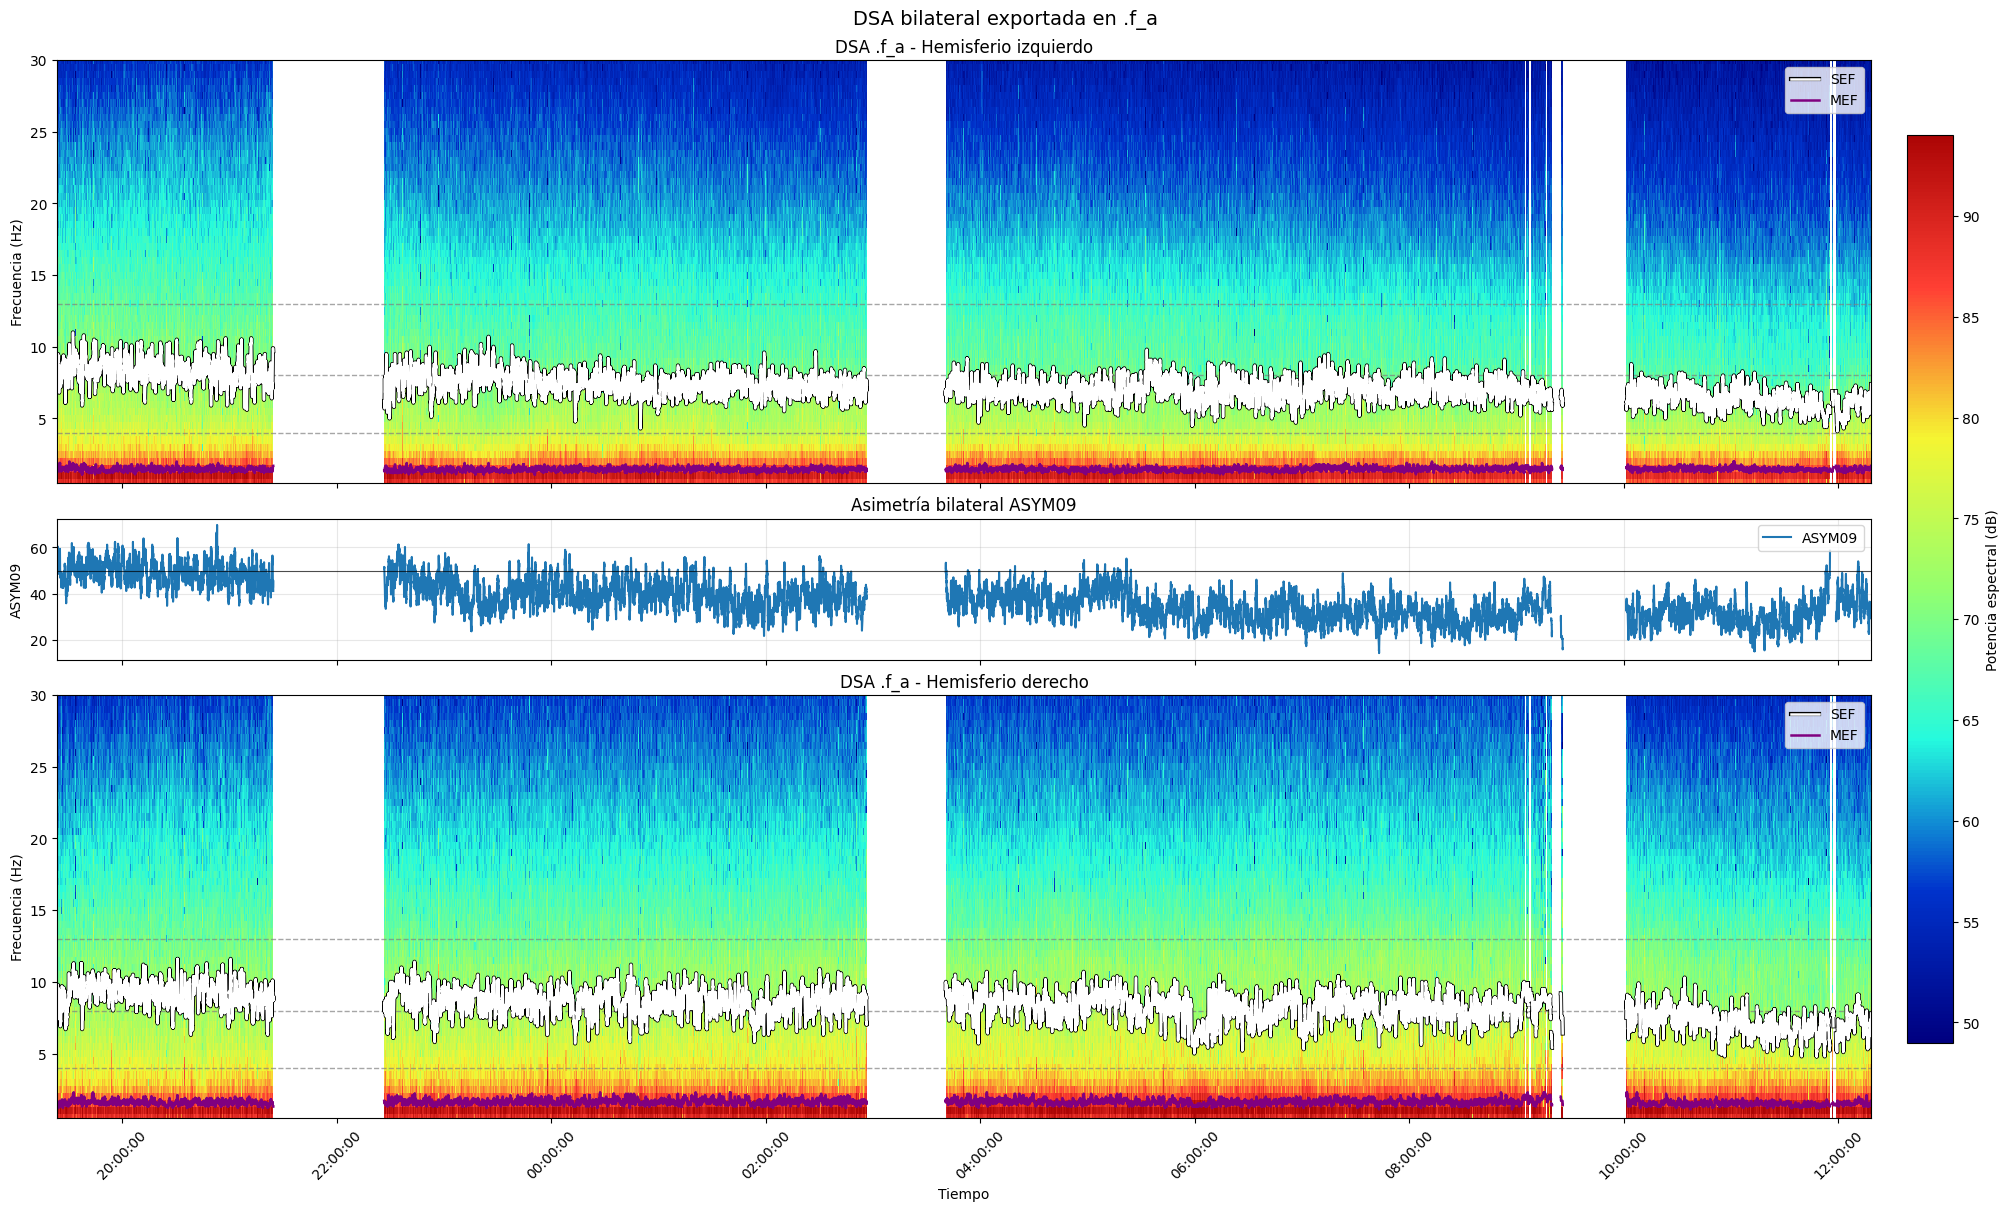

In [16]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_fa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_total_fa_bilat,
    mask_der=mask_total_fa_bilat,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a",
    etiqueta_colorbar="Potencia espectral (dB)"
)

### Cabecera

In [17]:
num_canales_bil, fs_bil, pendiente_bil, offset_bil = fau.extraer_parametros_eeg(ruta_ha_bilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales_bil}")
print(f" - Frecuencia (Hz): {fs_bil}")
print(f" - Pendiente (m): {pendiente_bil:.8f}")
print(f" - Offset (b): {offset_bil:.4f}")

Parámetros extraídos con éxito:
 - Canales: 4
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 2. 3. Archivo ondas crudas .r4a

In [18]:
df_eeg_bilateral = fun_dsa_b.leer_r4a(
    archivo_r4a, 
    pendiente_bil,
    offset_bil, 
    fs=fs_bil)

In [19]:
# 2. Alinear raw al tamaño y timeline del .spa
df_eeg_bilat_recortado, timeline_spa_bilat, info_alineacion = (
    fun_dsa_b.recortar_raw_segun_ta_y_spa(
        df_raw=df_eeg_bilateral,
        ruta_ta=ruta_ta_bilat,
        df_spa=df_spa_bilat,
        columna_time="Time",
        fs=128,
        resolver_duplicados="last",
        verbose=True
    )
)

# 3. Usar el inicio del .spa como inicio de la DSA reconstruida
hora_inicio = timeline_spa_bilat.iloc[0]

=== Alineación temporal raw vs spa ===
Inicio raw (.t_a): 2026-04-30 19:23:28
Inicio .spa: 2026-04-30 19:23:29
Desfase spa - raw: 1.0 s
Acción aplicada: recorte_inicio
Filas .spa: 60889
Muestras objetivo: 7793792
Muestras raw originales: 7793920
Muestras recortadas al inicio: 128
Muestras NaN añadidas al inicio: 0
Muestras NaN añadidas al final: 0
Muestras raw alineado: 7793792
Duración raw alineado: 60889.0 s
Raw bilateral original: (7793920, 9)
Raw bilateral recortado: (7793792, 9)


### 2. 3. 1. Reconstrucción

In [21]:
# ============================================================
# 2.2. Reconstrucción DSA por canal
# ============================================================

ventana_welch_s = 1
paso_welch_s = 1

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_1_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_2_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal3, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_3_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal4, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_4_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

In [22]:
# Combinación por hemisferio en escala lineal

cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# Izquierda: canal 1 + canal 2
pot_media_izq = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

# Derecha: canal 3 + canal 4
pot_media_der = (
    df_dsa_canal3[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal4[cols_freq].to_numpy(dtype=float)
) / 2

df_dsa_izq = df_dsa_canal1.copy()
df_dsa_der = df_dsa_canal3.copy()

In [23]:
# Conversión a dB para visualización

ref_potencia = 0.0001

df_dsa_izq[cols_freq] = 10 * np.log10(
    (pot_media_izq + 1e-12) / (ref_potencia ** 2)
)

df_dsa_der[cols_freq] = 10 * np.log10(
    (pot_media_der + 1e-12) / (ref_potencia ** 2)
)

### 2. 3. 2. Adaptación temporal, máscara y plot de DSA EEG

In [24]:
df_spa_bilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_bilat
)

tiempo_eeg_bilat, dsa_eeg_izq = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_izq,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

_, dsa_eeg_der = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_der,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

In [25]:
df_spa_izq = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="izq",
    verbose=False
)

df_spa_der = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="der",
    verbose=False
)

df_merge_eeg_izq = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg_bilat,
    df_spa=df_spa_izq
)

df_merge_eeg_der = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg_bilat,
    df_spa=df_spa_der
)

Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.
Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.


In [26]:
# Máscaras de calidad bilateral

_, mask_total_izq = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg_bilat,
    dsa=dsa_eeg_izq,
    df_merge=df_merge_eeg_izq,
    umbral_sqi=15,
    umbral_ceros=0.9
)

_, mask_total_der = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg_bilat,
    dsa=dsa_eeg_der,
    df_merge=df_merge_eeg_der,
    umbral_sqi=15,
    umbral_ceros=0.9
)

# Máscara común para que izquierda y derecha tengan bandas blancas alineadas
mask_total_bilat = mask_total_izq | mask_total_der

dsa_eeg_izq_plot = dsa_eeg_izq.copy()
dsa_eeg_der_plot = dsa_eeg_der.copy()

dsa_eeg_izq_plot.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_plot.loc[mask_total_bilat.values, :] = np.nan

### 2. 3. 3. Preparar escala de color de f_a y eeg reconstruida

In [27]:
matriz_eeg_izq, matriz_eeg_der, vmin_eeg, vmax_eeg, norm_eeg_bilat, cmap_eeg_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_plot,
        dsa_eeg_der_plot,
        gamma=0.55
    )
)

print("Reconstruida bilateral")
print("vmin:", vmin_eeg)
print("vmax:", vmax_eeg)

Reconstruida bilateral
vmin: 51.95122493305446
vmax: 105.06410413854962


### 2. 3. 4. Visualizar reconstruidas desde .r4a

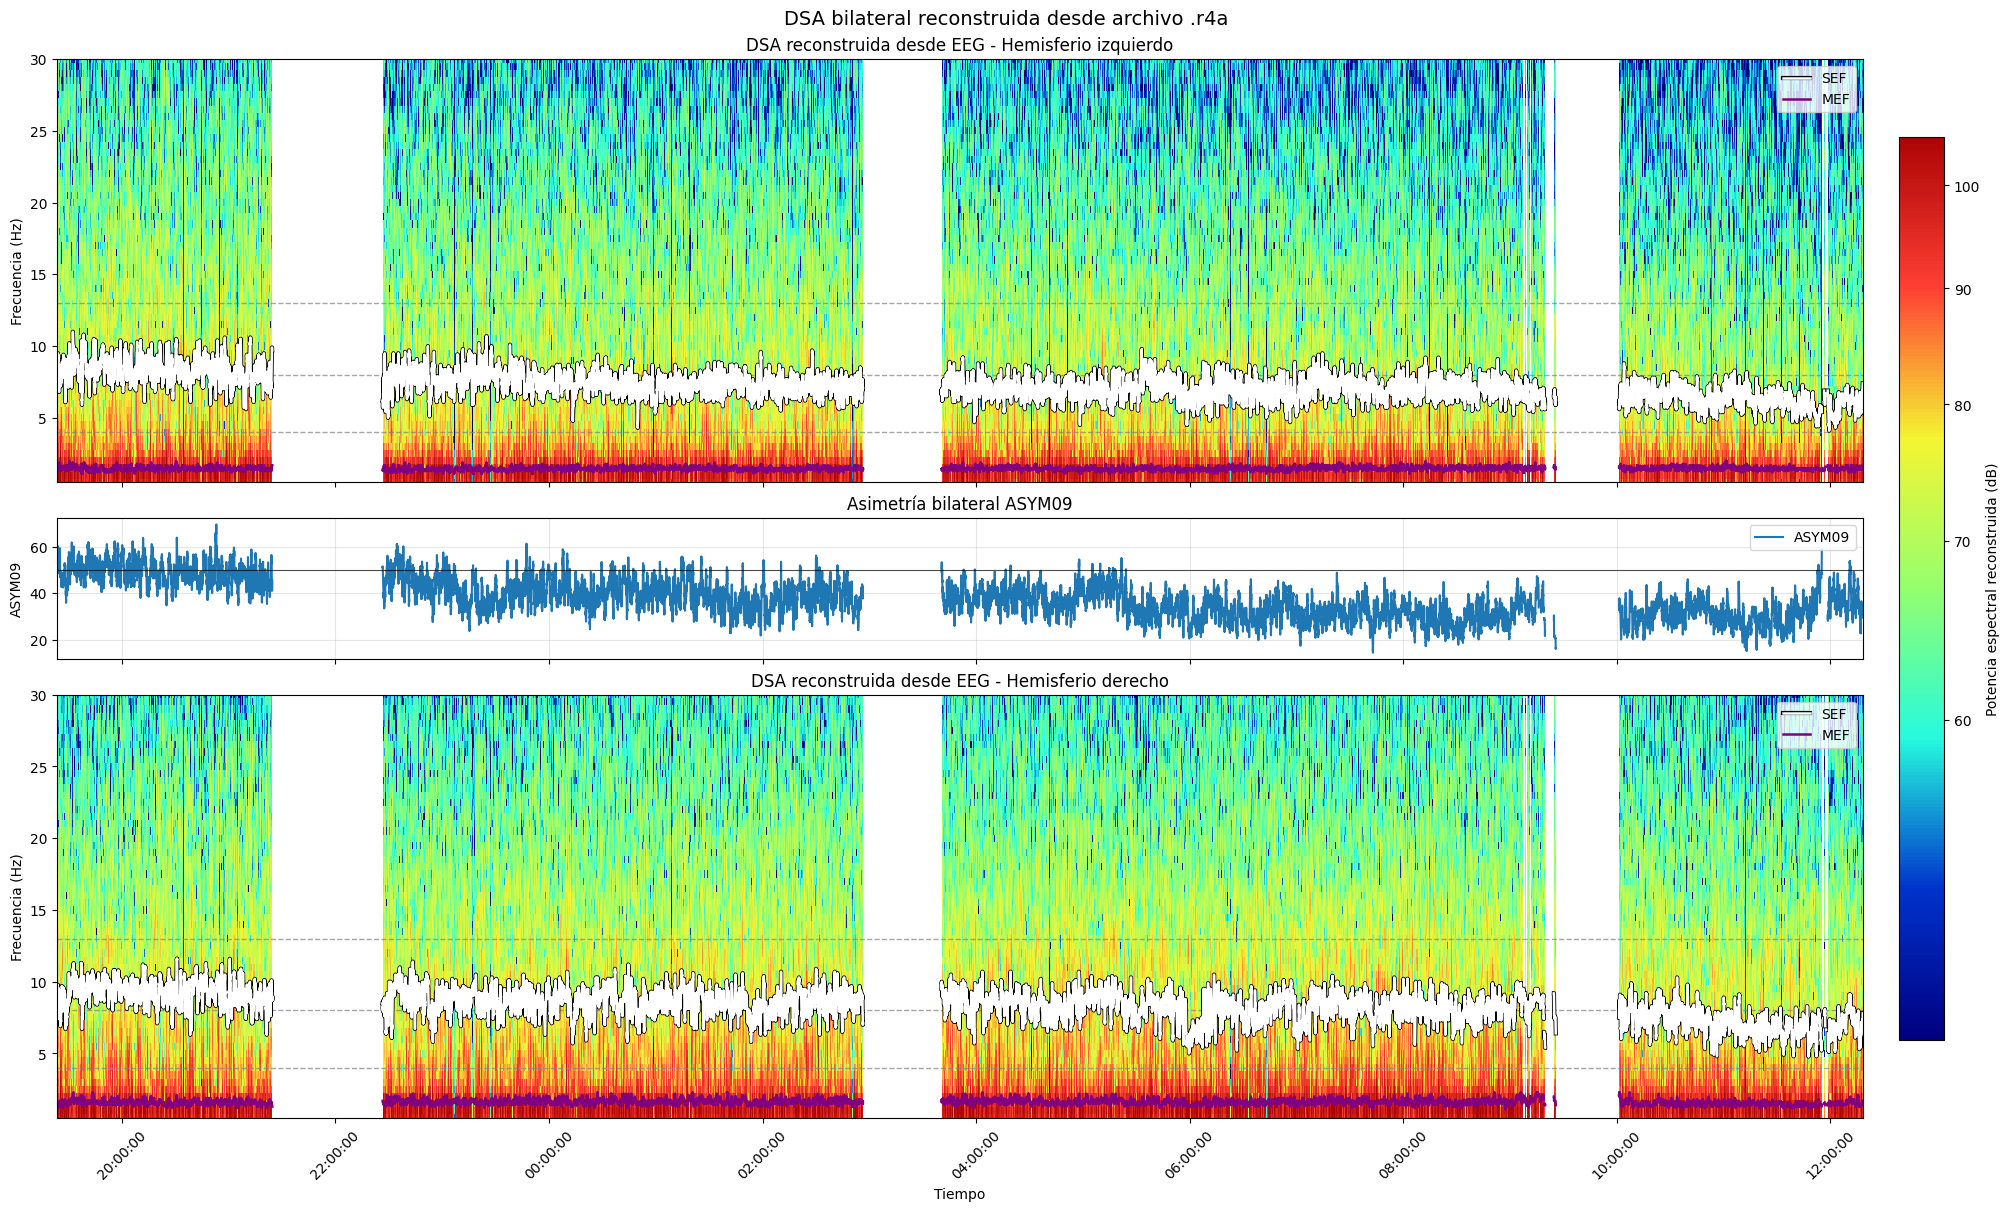

In [28]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_eeg_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)

In [29]:
cols_freq_eeg_L = [c for c in dsa_eeg_izq_plot.columns]

print("Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_izq_plot[cols_freq_eeg_L].values))
print(np.nanmax(dsa_eeg_izq_plot[cols_freq_eeg_L].values))

print("Percentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 2))
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN
24.955712494443084
136.5202981634223
Percentiles mínimos y máximos hemisferio izquierdo
50.706524385638836
103.77735568340621


In [30]:
cols_freq_fa_L = [c for c in dsa_plot_fa_L_mask.columns]

print("Mínimos y máximos hemisferio izquierdo - FA")
print(np.nanmin(dsa_plot_fa_L_mask[cols_freq_fa_L].values))
print(np.nanmax(dsa_plot_fa_L_mask[cols_freq_fa_L].values))

print("Percentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 2))
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - FA
35.25
97.08
Percentiles mínimos y máximos hemisferio izquierdo
52.53
91.23


In [31]:
cols_freq_eeg_R = [c for c in dsa_eeg_der_plot.columns]

print("Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_der_plot[cols_freq_eeg_R].values))
print(np.nanmax(dsa_eeg_der_plot[cols_freq_eeg_R].values))

print("Percentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 2))
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 99.5))

Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN
27.20021403368633
136.8943006774285
Percentiles mínimos y máximos hemisferio derecho
53.8972716749933
105.77170506729252


In [32]:
cols_freq_fa_R = [c for c in dsa_plot_fa_R_mask.columns]

print("Mínimos y máximos hemisferio derecho - FA")
print(np.nanmin(dsa_plot_fa_R_mask[cols_freq_fa_R].values))
print(np.nanmax(dsa_plot_fa_R_mask[cols_freq_fa_R].values))

print("Percentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 2))
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 99.5))

Mínimos y máximos hemisferio derecho - FA
35.03
101.04
Percentiles mínimos y máximos hemisferio derecho
56.05
93.39


# Métricas y comparación

In [33]:
# ============================================================
# Comparación base bilateral: EEG reconstruida vs .f_a
# ============================================================

# Izquierda
dsa_eeg_L_comp, dsa_fa_L_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_izq_plot,
    dsa_plot_fa_L_mask
)

dsa_eeg_L_z = fun_dsa.zscore_global(dsa_eeg_L_comp)
dsa_fa_L_z = fun_dsa.zscore_global(dsa_fa_L_comp)

metricas_base_L = fun_dsa.comparar_dsa_global(
    dsa_eeg_L_z,
    dsa_fa_L_z
)


# Derecha
dsa_eeg_R_comp, dsa_fa_R_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_der_plot,
    dsa_plot_fa_R_mask
)

dsa_eeg_R_z = fun_dsa.zscore_global(dsa_eeg_R_comp)
dsa_fa_R_z = fun_dsa.zscore_global(dsa_fa_R_comp)

metricas_base_R = fun_dsa.comparar_dsa_global(
    dsa_eeg_R_z,
    dsa_fa_R_z
)


# Resumen
df_metricas_base_bilat = pd.DataFrame([
    {
        "hemisferio": "izquierdo",
        **metricas_base_L
    },
    {
        "hemisferio": "derecho",
        **metricas_base_R
    }
])

display(df_metricas_base_bilat)

,hemisferio,n_valores_comparados,MAE,RMSE,bias_B_menos_A,Pearson,Spearman
0,izquierdo,3102900,0.414085,0.569936,0.000008,0.837578,0.802703
1,derecho,3102900,0.409522,0.541358,-0.000075,0.853462,0.821012


In [34]:
# ============================================================
# Correlación por frecuencia bilateral
# ============================================================

df_corr_freq_L = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_L_z,
    dsa_fa_L_z
)

df_corr_freq_L["hemisferio"] = "izquierdo"


df_corr_freq_R = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_R_z,
    dsa_fa_R_z
)

df_corr_freq_R["hemisferio"] = "derecho"


df_corr_freq_bilat = pd.concat(
    [df_corr_freq_L, df_corr_freq_R],
    ignore_index=True
)

display(df_corr_freq_bilat.head())

,frecuencia_Hz,correlacion,hemisferio
0,0.5,0.079906,izquierdo
1,1.0,0.085530,izquierdo
2,1.5,0.080288,izquierdo
3,2.0,0.056305,izquierdo
4,2.5,0.043191,izquierdo


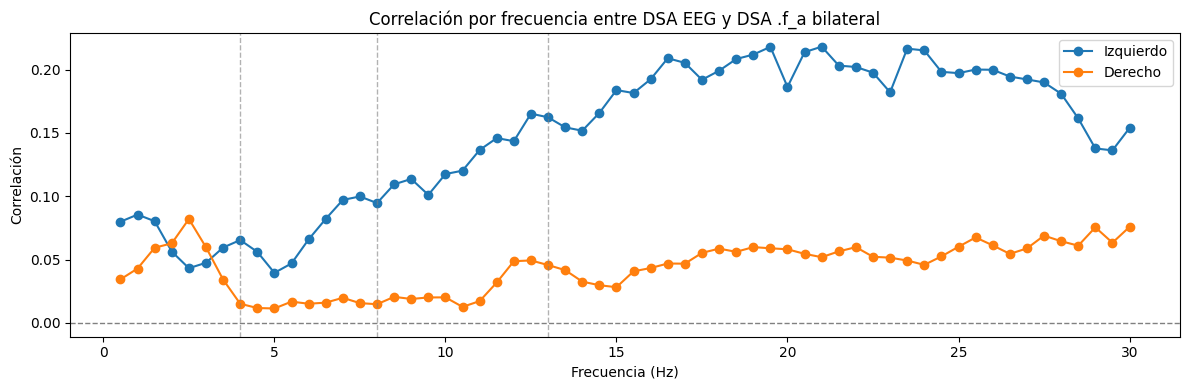

In [35]:
plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq_L["frecuencia_Hz"],
    df_corr_freq_L["correlacion"],
    marker="o",
    label="Izquierdo"
)

plt.plot(
    df_corr_freq_R["frecuencia_Hz"],
    df_corr_freq_R["correlacion"],
    marker="o",
    label="Derecho"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA .f_a bilateral")
plt.legend()
plt.tight_layout()
plt.show()

### Suavizado + shift

In [37]:
# ============================================================
# Suavizado + shift bilateral
# ============================================================

ventanas_sp_smooth = [5, 10, 30, 60]
shifts_prueba = range(-10, 30)

# Izquierda
df_suav_shift_L = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_L_comp,
    dsa_fa_L_comp,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=shifts_prueba
)

df_suav_shift_L = df_suav_shift_L.rename(columns={
    "Pearson": "Pearson_L",
    "Spearman": "Spearman_L",
    "MAE": "MAE_L",
    "RMSE": "RMSE_L"
})


# Derecha
df_suav_shift_R = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_R_comp,
    dsa_fa_R_comp,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=shifts_prueba
)

df_suav_shift_R = df_suav_shift_R.rename(columns={
    "Pearson": "Pearson_R",
    "Spearman": "Spearman_R",
    "MAE": "MAE_R",
    "RMSE": "RMSE_R"
})


# Unir por suavizado y shift
df_suav_shift_bilat = df_suav_shift_L.merge(
    df_suav_shift_R,
    on=["suavizado_s", "shift_s"],
    how="inner"
)


# Métricas medias bilaterales
df_suav_shift_bilat["Pearson_medio"] = (
    df_suav_shift_bilat["Pearson_L"] +
    df_suav_shift_bilat["Pearson_R"]
) / 2

df_suav_shift_bilat["Spearman_medio"] = (
    df_suav_shift_bilat["Spearman_L"] +
    df_suav_shift_bilat["Spearman_R"]
) / 2

df_suav_shift_bilat["MAE_medio"] = (
    df_suav_shift_bilat["MAE_L"] +
    df_suav_shift_bilat["MAE_R"]
) / 2

df_suav_shift_bilat["RMSE_medio"] = (
    df_suav_shift_bilat["RMSE_L"] +
    df_suav_shift_bilat["RMSE_R"]
) / 2


# Ver mejores combinaciones
display(
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .head(10)
)

,suavizado_s,shift_s,Pearson_L,Spearman_L,MAE_L,RMSE_L,Pearson_R,Spearman_R,MAE_R,RMSE_R,Pearson_medio,Spearman_medio,MAE_medio,RMSE_medio
137,60,7,0.982795,0.986174,0.136616,0.185136,0.980204,0.983817,0.146081,0.198967,0.981499,0.984996,0.141348,0.192052
136,60,6,0.982775,0.986170,0.136530,0.185245,0.980217,0.983840,0.145982,0.198902,0.981496,0.985005,0.141256,0.192073
135,60,5,0.982737,0.986141,0.136525,0.185445,0.980217,0.983843,0.145958,0.198907,0.981477,0.984992,0.141241,0.192176
138,60,8,0.982787,0.986137,0.136836,0.185177,0.980167,0.983758,0.146304,0.199153,0.981477,0.984947,0.141570,0.192165
134,60,4,0.982696,0.986108,0.136540,0.185669,0.980214,0.983841,0.145954,0.198923,0.981455,0.984975,0.141247,0.192296
139,60,9,0.982753,0.986062,0.137176,0.185355,0.980108,0.983666,0.146639,0.199449,0.981431,0.984864,0.141908,0.192402
133,60,3,0.982650,0.986072,0.136570,0.185918,0.980209,0.983836,0.145964,0.198950,0.981429,0.984954,0.141267,0.192434
132,60,2,0.982600,0.986033,0.136610,0.186185,0.980202,0.983829,0.145988,0.198983,0.981401,0.984931,0.141299,0.192584
131,60,1,0.982557,0.986007,0.136639,0.186413,0.980208,0.983836,0.145993,0.198952,0.981383,0.984921,0.141316,0.192683
130,60,0,0.982517,0.985984,0.136663,0.186630,0.980224,0.983853,0.145983,0.198873,0.981370,0.984919,0.141323,0.192751


### Elegir mejor suavizado + shift bilateral

In [39]:
mejor_bilat_pearson = (
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .iloc[0]
)

mejor_bilat_spearman = (
    df_suav_shift_bilat
    .sort_values("Spearman_medio", ascending=False)
    .iloc[0]
)

df_resumen_final_bilat = pd.DataFrame([
    {
        "criterio": "Mejor Pearson medio",
        "suavizado_s": mejor_bilat_pearson["suavizado_s"],
        "shift_s": mejor_bilat_pearson["shift_s"],
        "Pearson_L": mejor_bilat_pearson["Pearson_L"],
        "Pearson_R": mejor_bilat_pearson["Pearson_R"],
        "Pearson_medio": mejor_bilat_pearson["Pearson_medio"],
        "Spearman_L": mejor_bilat_pearson["Spearman_L"],
        "Spearman_R": mejor_bilat_pearson["Spearman_R"],
        "Spearman_medio": mejor_bilat_pearson["Spearman_medio"],
        "MAE_medio": mejor_bilat_pearson["MAE_medio"],
        "RMSE_medio": mejor_bilat_pearson["RMSE_medio"],
    },
    {
        "criterio": "Mejor Spearman medio",
        "suavizado_s": mejor_bilat_spearman["suavizado_s"],
        "shift_s": mejor_bilat_spearman["shift_s"],
        "Pearson_L": mejor_bilat_spearman["Pearson_L"],
        "Pearson_R": mejor_bilat_spearman["Pearson_R"],
        "Pearson_medio": mejor_bilat_spearman["Pearson_medio"],
        "Spearman_L": mejor_bilat_spearman["Spearman_L"],
        "Spearman_R": mejor_bilat_spearman["Spearman_R"],
        "Spearman_medio": mejor_bilat_spearman["Spearman_medio"],
        "MAE_medio": mejor_bilat_spearman["MAE_medio"],
        "RMSE_medio": mejor_bilat_spearman["RMSE_medio"],
    }
])

display(df_resumen_final_bilat)

,criterio,suavizado_s,shift_s,Pearson_L,Pearson_R,Pearson_medio,Spearman_L,Spearman_R,Spearman_medio,MAE_medio,RMSE_medio
0,Mejor Pearson medio,60.0,7.0,0.982795,0.980204,0.981499,0.986174,0.983817,0.984996,0.141348,0.192052
1,Mejor Spearman medio,60.0,6.0,0.982775,0.980217,0.981496,0.986170,0.983840,0.985005,0.141256,0.192073


In [40]:
suavizado_final_bilat = int(mejor_bilat_pearson["suavizado_s"])
shift_final_bilat = int(mejor_bilat_pearson["shift_s"])

print("Suavizado final bilateral:", suavizado_final_bilat)
print("Shift final bilateral:", shift_final_bilat)

Suavizado final bilateral: 60
Shift final bilateral: 7


## Suavizado limpio

In [42]:
# ============================================================
# Suavizado temporal bilateral
# ============================================================

suavizado_final_bilat = 60

dsa_eeg_izq_suav = dsa_eeg_izq.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()

dsa_eeg_der_suav = dsa_eeg_der.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()

## Aplicar máscara común al final

In [43]:
# ============================================================
# Aplicar máscara común bilateral al final
# ============================================================

dsa_eeg_izq_suav_plot = dsa_eeg_izq_suav.copy()
dsa_eeg_der_suav_plot = dsa_eeg_der_suav.copy()

dsa_eeg_izq_suav_plot.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_suav_plot.loc[mask_total_bilat.values, :] = np.nan

## Preparar escala de color común para suavizadas

In [44]:
# ============================================================
# Escala común para DSA suavizadas izquierda/derecha
# ============================================================

matriz_suav_izq, matriz_suav_der, vmin_suav, vmax_suav, norm_suav_bilat, cmap_suav_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_plot,
        dsa_eeg_der_suav_plot,
        gamma=0.55
    )
)

print("Rango suavizada bilateral:")
print("vmin:", vmin_suav)
print("vmax:", vmax_suav)

Rango suavizada bilateral:
vmin: 57.01835756677562
vmax: 99.92697007584246


### Comprobación de bandas blancas

In [45]:
# ============================================================
# Comprobación de bandas blancas
# ============================================================

mask_blanca_izq_directa = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_der_directa = dsa_eeg_der_plot.isna().all(axis=1)

mask_blanca_izq_suav = dsa_eeg_izq_suav_plot.isna().all(axis=1)
mask_blanca_der_suav = dsa_eeg_der_suav_plot.isna().all(axis=1)

print("Bandas blancas izquierda directa vs suavizada:")
print((mask_blanca_izq_directa == mask_blanca_izq_suav).all())
print("Diferencias izquierda:", (mask_blanca_izq_directa != mask_blanca_izq_suav).sum())

print("\nBandas blancas derecha directa vs suavizada:")
print((mask_blanca_der_directa == mask_blanca_der_suav).all())
print("Diferencias derecha:", (mask_blanca_der_directa != mask_blanca_der_suav).sum())

Bandas blancas izquierda directa vs suavizada:
True
Diferencias izquierda: 0

Bandas blancas derecha directa vs suavizada:
True
Diferencias derecha: 0


## Aplicar shift bilateral manteniendo duración original

In [46]:
# ============================================================
# Suavizado + shift bilateral manteniendo duración original
# ============================================================

shift_final_bilat = 7

# Matrices vacías del mismo tamaño
dsa_eeg_izq_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_izq_suav.index,
    columns=dsa_eeg_izq_suav.columns
)

dsa_eeg_der_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_der_suav.index,
    columns=dsa_eeg_der_suav.columns
)

# Desplazar hacia delante
dsa_eeg_izq_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_izq_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

dsa_eeg_der_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_der_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

# Aplicar máscara común bilateral al final
dsa_eeg_izq_suav_shift_full.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_suav_shift_full.loc[mask_total_bilat.values, :] = np.nan

## Escala común para suavizada + shift

In [47]:
# ============================================================
# Escala común para DSA suavizadas + shift
# ============================================================

matriz_shift_izq, matriz_shift_der, vmin_shift, vmax_shift, norm_shift_bilat, cmap_shift_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_shift_full,
        dsa_eeg_der_suav_shift_full,
        gamma=0.55
        
    )
)

print("Rango suavizada + shift bilateral:")
print("vmin:", vmin_shift)
print("vmax:", vmax_shift)

Rango suavizada + shift bilateral:
vmin: 57.0188234189183
vmax: 99.93026234060524


In [49]:
print(tiempo_fa_bilat)
print(tiempo_eeg_bilat)

0       2026-04-30 19:23:28
1       2026-04-30 19:23:29
2       2026-04-30 19:23:30
3       2026-04-30 19:23:31
4       2026-04-30 19:23:32
                ...        
60885   2026-05-01 12:18:12
60886   2026-05-01 12:18:13
60887   2026-05-01 12:18:14
60888   2026-05-01 12:18:15
60889   2026-05-01 12:18:16
Name: Time, Length: 60890, dtype: datetime64[ns]
0       2026-04-30 19:23:29
1       2026-04-30 19:23:30
2       2026-04-30 19:23:31
3       2026-04-30 19:23:32
4       2026-04-30 19:23:33
                ...        
60884   2026-05-01 12:18:13
60885   2026-05-01 12:18:14
60886   2026-05-01 12:18:15
60887   2026-05-01 12:18:16
60888   2026-05-01 12:18:17
Name: Time, Length: 60889, dtype: datetime64[ns]


### Comprobación de formas

In [48]:
# ============================================================
# Comprobación de formas y tiempos
# ============================================================

print("DSA f_a izquierda:", dsa_plot_fa_L_mask.shape)
print("DSA f_a derecha:", dsa_plot_fa_R_mask.shape)

print("DSA EEG izquierda directa:", dsa_eeg_izq_plot.shape)
print("DSA EEG derecha directa:", dsa_eeg_der_plot.shape)

print("DSA EEG izquierda suavizada:", dsa_eeg_izq_suav_plot.shape)
print("DSA EEG derecha suavizada:", dsa_eeg_der_suav_plot.shape)

print("DSA EEG izquierda suavizada + shift:", dsa_eeg_izq_suav_shift_full.shape)
print("DSA EEG derecha suavizada + shift:", dsa_eeg_der_suav_shift_full.shape)

print("\n¿Tiempos f_a y EEG iguales?")
print((tiempo_fa_bilat.reset_index(drop=True) == tiempo_eeg_bilat.reset_index(drop=True)).all())

print("\nRango DSA EEG izquierda directa:")
print(np.nanmin(dsa_eeg_izq_plot.values), np.nanmax(dsa_eeg_izq_plot.values))

print("\nRango DSA EEG derecha directa:")
print(np.nanmin(dsa_eeg_der_plot.values), np.nanmax(dsa_eeg_der_plot.values))

print("\nRango DSA f_a izquierda:")
print(np.nanmin(dsa_plot_fa_L_mask.values), np.nanmax(dsa_plot_fa_L_mask.values))

print("\nRango DSA f_a derecha:")
print(np.nanmin(dsa_plot_fa_R_mask.values), np.nanmax(dsa_plot_fa_R_mask.values))

print("\nRango DSA suavizada + shift izquierda:")
print(np.nanmin(dsa_eeg_izq_suav_shift_full.values), np.nanmax(dsa_eeg_izq_suav_shift_full.values))

print("\nRango DSA suavizada + shift derecha:")
print(np.nanmin(dsa_eeg_der_suav_shift_full.values), np.nanmax(dsa_eeg_der_suav_shift_full.values))

DSA f_a izquierda: (60890, 60)
DSA f_a derecha: (60890, 60)
DSA EEG izquierda directa: (60889, 60)
DSA EEG derecha directa: (60889, 60)
DSA EEG izquierda suavizada: (60889, 60)
DSA EEG derecha suavizada: (60889, 60)
DSA EEG izquierda suavizada + shift: (60889, 60)
DSA EEG derecha suavizada + shift: (60889, 60)

¿Tiempos f_a y EEG iguales?


ValueError: Can only compare identically-labeled Series objects

## Visualizar suavizada + shift bilateral

In [ ]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_eeg_bilat,
    frecuencias=dsa_eeg_izq_suav_shift_full.columns.astype(float),
    matriz_izq=matriz_shift_izq,
    matriz_der=matriz_shift_der,
    norm=norm_shift_bilat,
    cmap=cmap_shift_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida suavizada + shift - Hemisferio izquierdo",
    titulo_der="DSA reconstruida suavizada + shift - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde .r4a con suavizado y shift",
    etiqueta_colorbar="Intensidad espectral reconstruida (dB)"
)

In [ ]:
fig_eeg, axes_eeg = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_eeg_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)

In [ ]:
fig_fa, axes_fa = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_fa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_total_fa_bilat,
    mask_der=mask_total_fa_bilat,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a",
    etiqueta_colorbar="Potencia espectral (dB)"
)

In [ ]:
ruta_spa_bilat_h = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.spa"
df_spa_raw_h = fau.procesar_spa(ruta_spa_bilat_h)

df_spa_limpio_h = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_h)


display(df_spa_limpio_h.head())